# <span style="color:yellow;">Multi-class</span>

# Step 1: Import necessary libraries

In [35]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns
from skimage import data
from skimage.filters import threshold_multiotsu
from skimage.transform import resize
from skimage.util import img_as_ubyte
from scipy import ndimage

In [36]:
# Set plotting style and parameters
sns.set_style('whitegrid')
plt.rcParams.update({   # Runtime Configuration Parameters
    'figure.figsize': (12, 8),
    'figure.dpi': 100,  # Sharper images for display
    'font.size': 10     # Consistent font size
})

In [37]:
# Informative startup message
print("✅ Libraries imported successfully (numpy, matplotlib, skimage, scipy).")
print("🔍 Starting multi-level Otsu thresholding demo (for grayscale image segmentation)...")

✅ Libraries imported successfully (numpy, matplotlib, skimage, scipy).
🔍 Starting multi-level Otsu thresholding demo (for grayscale image segmentation)...


# Step 2: Load and resize image (with detailed checks)

In [38]:
# Load sample image and check basic properties
image = Image.open("7.jpg")
# 转化为灰度图
image = image.convert("L")
original_img = np.array(image)  # 转换为NumPy数组
# original_img = data.camera()
h_original, w_original = original_img.shape
dtype_original = original_img.dtype
intensity_range_original = (original_img.min(), original_img.max())

In [39]:
# Print COMPLETE original image info (not just shape)
print(f"\n📊 Original Image Properties:")
print(f"   - Dimensions: {h_original}px (height) × {w_original}px (width)")
print(f"   - Data type: {dtype_original}")
print(f"   - Intensity range (black → white): {intensity_range_original[0]} → {intensity_range_original[1]}")
print(f"   - Total pixels: {h_original * w_original:,}")  # Add commas for readability


📊 Original Image Properties:
   - Dimensions: 3072px (height) × 4096px (width)
   - Data type: uint8
   - Intensity range (black → white): 0 → 228
   - Total pixels: 12,582,912


In [40]:
# Resize logic (preserve aspect ratio, cap at 256px max dimension)
max_size = 256
scale = min(max_size / h_original, max_size / w_original)  # Scale to fit max_size
h_resized, w_resized = int(h_original * scale), int(w_original * scale)

In [41]:
# Resize and convert to 8-bit (ubyte) for consistency
resized_img = resize(
    original_img, 
    (h_resized, w_resized), 
    anti_aliasing=True,  # Reduce jagged edges
    preserve_range=True  # Keep intensity values (0-255)
)
resized_img = resized_img / 255.0  # Normalize to 0-1 range first
resized_img = img_as_ubyte(resized_img)  # Convert to 8-bit (0-255)

In [42]:
# Calculate intensity range **after** conversion (now it's defined)
intensity_range_resized = (resized_img.min(), resized_img.max())

In [43]:
# Print resized image info (now intensity_range_resized exists)
print(f"\n📏 Resized Image Properties (aspect ratio preserved):")
print(f"   - Dimensions: {h_resized}px (height) × {w_resized}px (width)")
print(f"   - Scaling factor applied: {scale:.2f}x")
print(f"   - Intensity range (after resizing): {intensity_range_resized[0]} → {intensity_range_resized[1]}")
print(f"   - Total pixels: {h_resized * w_resized:,}")


📏 Resized Image Properties (aspect ratio preserved):
   - Dimensions: 192px (height) × 256px (width)
   - Scaling factor applied: 0.06x
   - Intensity range (after resizing): 6 → 223
   - Total pixels: 49,152


# Step 3: Display original vs resized

In [44]:
# Add pixel dimensions to titles for clarity
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Original image (with dimensions in title)
axes[0].imshow(original_img, cmap='gray')
axes[0].set_title(f'Original Image\n{h_original}×{w_original} px', fontsize=11)
axes[0].axis('off')

# Resized image (with scaling factor in title)
axes[1].imshow(resized_img, cmap='gray')
axes[1].set_title(f'Resized Image (Max 256px)\n{h_resized}×{w_resized} px (×{scale:.2f})', fontsize=11)
axes[1].axis('off')

plt.tight_layout()

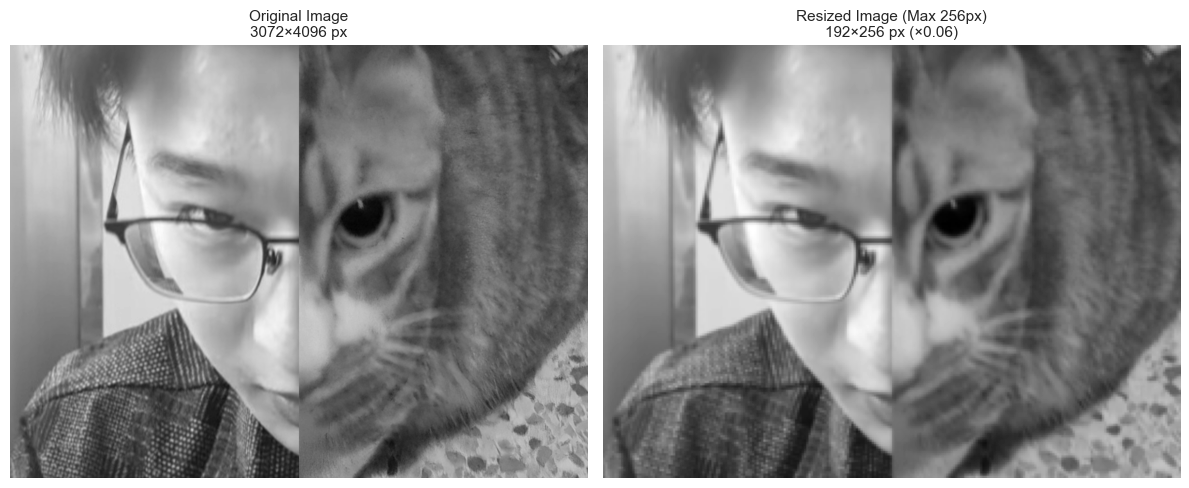

In [45]:
plt.show()

In [46]:
print("\n🖼️ Original and resized images displayed (resized to avoid slow processing).")


🖼️ Original and resized images displayed (resized to avoid slow processing).


# Step 4: Compute multi-level Otsu thresholds (3 classes)

A thresholding technique (extending basic `Otsu’s method`) that automatically splits an image into multiple non-overlapping regions (e.g., `background`, `mid-tone`, `foreground`) by calculating $k$ optimal thresholds (for $k+1$ regions), instead of just 1 threshold.

* Let $k$ thresholds $T_1 < T_2 < ... < T_k$ split the image into $k+1$ regions:$R_0 = [0, T_1], R_1 = [T_1+1, T_2], ..., R_k = [T_k+1, 255]$.
* Works by minimizing the `within-class variance` $\sigma_W^2$ (variation of pixel intensities inside each region) across all $k+1$ regions, 
* while maximizing the `between-class variance` $\sigma_B^2$ (difference in intensities between regions)—ensuring clear separation of intensity groups.


* Ideal for images with multiple distinct intensity peaks:
    * (e.g., medical scans with tissue, bone, and background; 
    * or industrial images with defects of varying brightness),
    * where basic `2-region thresholding` would fail.

In [47]:
# Print threshold values with context (what they represent)
# Compute thresholds for 3 classes (background, mid-tone, foreground)
num_classes = 3
thresholds = threshold_multiotsu(resized_img, classes=num_classes)

In [48]:
# Print thresholds with clear labeling
print(f"\n🎯 Multi-Level Otsu Thresholds (for {num_classes} classes):")


🎯 Multi-Level Otsu Thresholds (for 3 classes):


In [49]:
for i, thresh in enumerate(thresholds):
    # Explain what each threshold does (e.g., "Thresh 1: Background ↔ Mid-tone")
    print(f"   - Threshold {i+1}: {thresh} (separates Class {i} ↔ Class {i+1})")

   - Threshold 1: 92 (separates Class 0 ↔ Class 1)
   - Threshold 2: 141 (separates Class 1 ↔ Class 2)


In [50]:
# Define class ranges for clarity (e.g., "Class 0: 0-78")
class_ranges = []
for i in range(num_classes):
    if i == 0:
        start = 0
        end = thresholds[i]
    elif i == num_classes - 1:
        start = thresholds[i-1]
        end = 255
    else:
        start = thresholds[i-1]
        end = thresholds[i]
    class_ranges.append(f"Class {i}: {start}–{end}")

In [51]:
print(f"\n📋 Intensity Ranges per Class:")
for range_str in class_ranges:
    print(f"   - {range_str}")


📋 Intensity Ranges per Class:
   - Class 0: 0–92
   - Class 1: 92–141
   - Class 2: 141–255


# Step 5: Segment image + Label regions with class numbers

In [52]:
# Add a colorbar to show which number maps to which class
# Segment the image into classes
regions = np.digitize(resized_img, bins=thresholds)

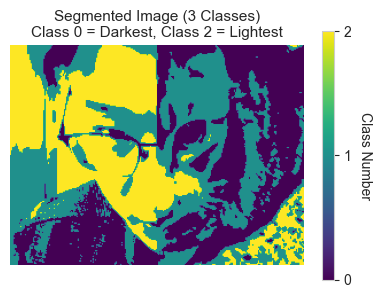

In [53]:
# Plot segmented image with colorbar (critical for interpreting classes)
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
im = ax.imshow(regions, cmap='viridis')  # 'viridis' is colorblind-friendly
ax.set_title(f'Segmented Image ({num_classes} Classes)\nClass 0 = Darkest, Class {num_classes-1} = Lightest', fontsize=11)
ax.axis('off')

# Add colorbar to map numbers to visual colors
cbar = plt.colorbar(im, ax=ax, ticks=range(num_classes))
cbar.set_label('Class Number', rotation=270, labelpad=15)  # Rotate label for readability

plt.tight_layout()
plt.show()

In [54]:
print(f"\n🗺️ Segmented image displayed with class labels (colorbar maps numbers to colors).")


🗺️ Segmented image displayed with class labels (colorbar maps numbers to colors).


# Step 6: Histogram + Thresholds + Class Intensity Zones

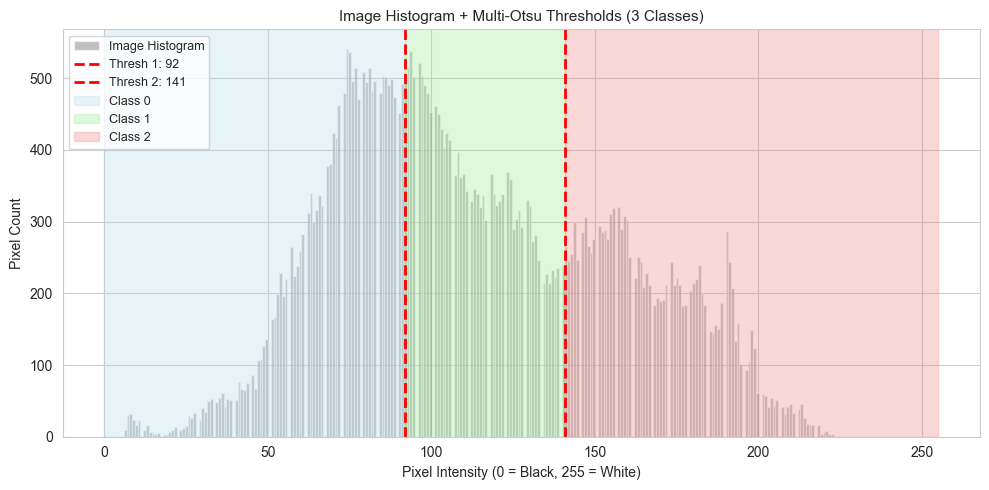

In [55]:
# Shade histogram regions to show which intensity ranges belong to which class
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# Plot full histogram
ax.hist(resized_img.ravel(), bins=256, color='gray', alpha=0.5, label='Image Histogram')

# Add vertical lines for thresholds
for i, thresh in enumerate(thresholds):
    ax.axvline(thresh, color='red', linestyle='--', linewidth=2, label=f'Thresh {i+1}: {thresh}')

# Shade histogram regions by class (visualize class ranges)
colors = ['lightblue', 'lightgreen', 'lightcoral']  # Match class order
for i in range(num_classes):
    if i == 0:
        ax.axvspan(0, thresholds[i], alpha=0.3, color=colors[i], label=f'Class {i}')
    elif i == num_classes - 1:
        ax.axvspan(thresholds[i-1], 255, alpha=0.3, color=colors[i], label=f'Class {i}')
    else:
        ax.axvspan(thresholds[i-1], thresholds[i], alpha=0.3, color=colors[i], label=f'Class {i}')

# Add labels and legend
ax.set_title(f'Image Histogram + Multi-Otsu Thresholds ({num_classes} Classes)', fontsize=11)
ax.set_xlabel('Pixel Intensity (0 = Black, 255 = White)')
ax.set_ylabel('Pixel Count')
ax.legend(loc='upper left', fontsize=9)  # Avoid overlapping with histogram peaks

plt.tight_layout()
plt.show()

In [56]:
print("\n📊 Histogram displayed with shaded class zones (easy to see intensity ranges per class).")


📊 Histogram displayed with shaded class zones (easy to see intensity ranges per class).


# Step 7: Compare 2, 3, 4 classes + Side-by-Side Histograms

In [57]:
# Avoid overcrowding one histogram—use separate histograms for each class count
classes_list = [2, 3, 4]

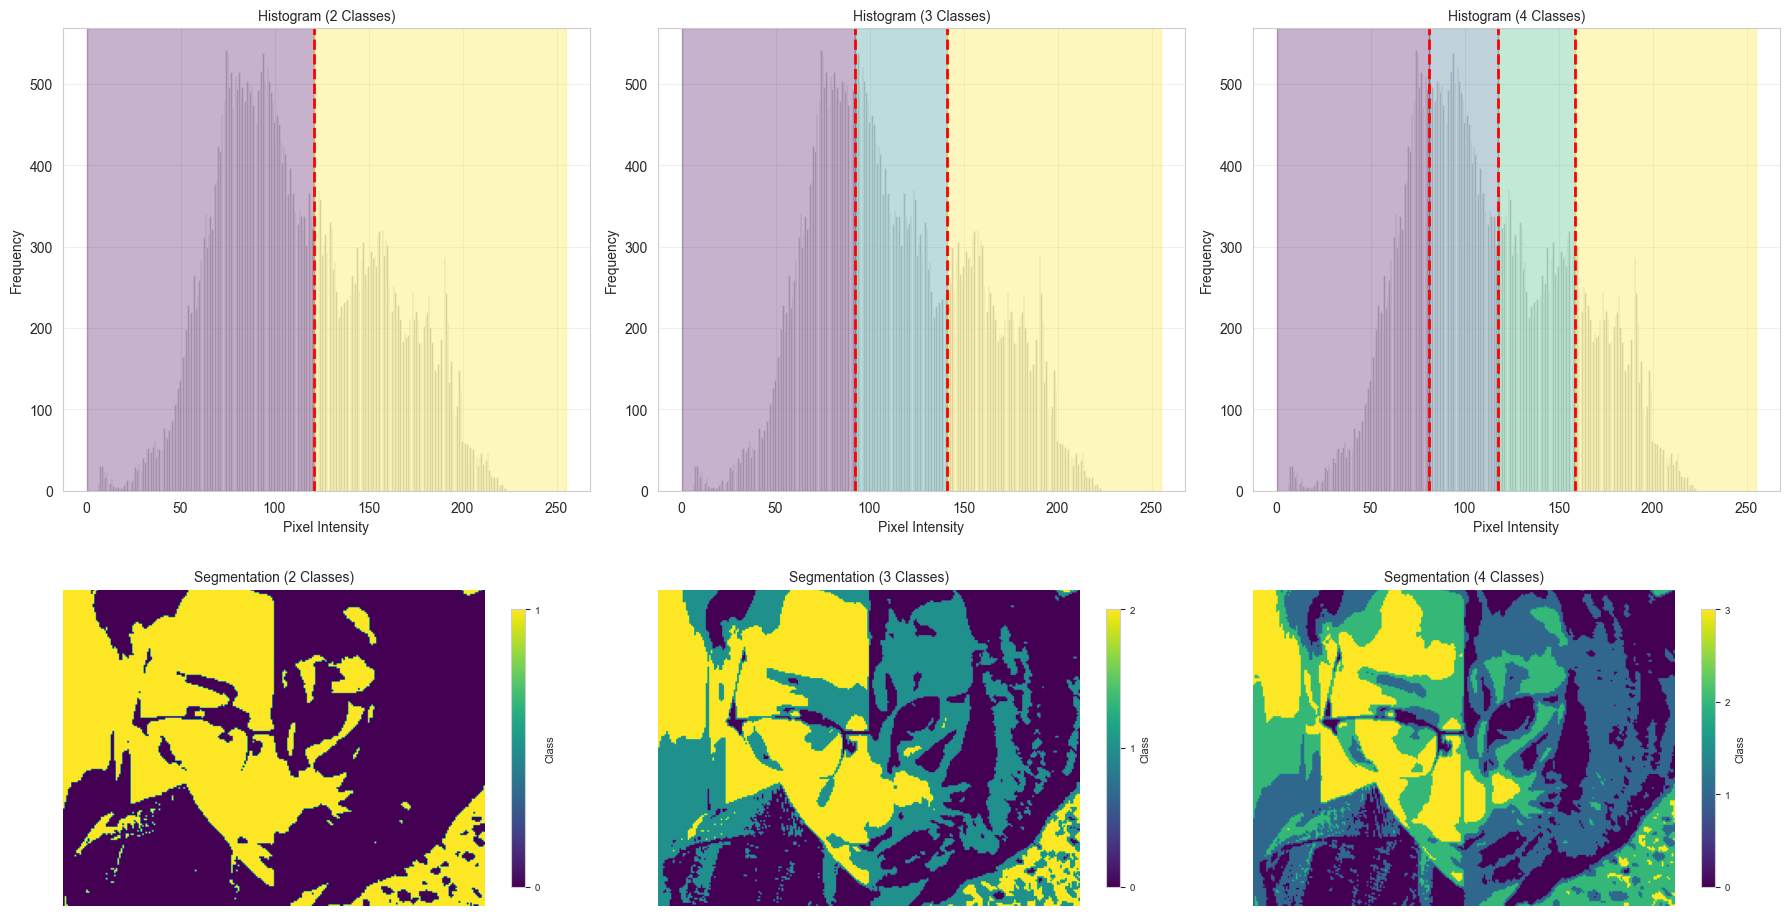

In [58]:
fig, axes = plt.subplots(2, len(classes_list), figsize=(18, 10))  # 2 rows: histograms + segmentations

# Loop through each class count (2, 3, 4)
for idx, num_classes in enumerate(classes_list):
    # Compute thresholds and segment
    thresholds = threshold_multiotsu(resized_img, classes=num_classes)
    seg = np.digitize(resized_img, bins=thresholds)
    
    # --------------------------
    # Row 1: Histogram with thresholds
    # --------------------------
    ax_hist = axes[0, idx]
    # Plot histogram
    ax_hist.hist(resized_img.ravel(), bins=256, color='gray', alpha=0.5)
    # Add thresholds
    for thresh in thresholds:
        ax_hist.axvline(thresh, color='red', linestyle='--', linewidth=2)
    # Shade class zones
    colors = plt.cm.viridis(np.linspace(0, 1, num_classes))  # Colorblind-friendly palette
    for i in range(num_classes):
        if i == 0:
            ax_hist.axvspan(0, thresholds[i], alpha=0.3, color=colors[i])
        elif i == num_classes - 1:
            ax_hist.axvspan(thresholds[i-1], 255, alpha=0.3, color=colors[i])
        else:
            ax_hist.axvspan(thresholds[i-1], thresholds[i], alpha=0.3, color=colors[i])
    # Format histogram
    ax_hist.set_title(f'Histogram ({num_classes} Classes)', fontsize=10)
    ax_hist.set_xlabel('Pixel Intensity')
    ax_hist.set_ylabel('Frequency')
    ax_hist.grid(alpha=0.3)  # Light grid for readability
    
    # --------------------------
    # Row 2: Segmented image with colorbar
    # --------------------------
    ax_seg = axes[1, idx]
    im = ax_seg.imshow(seg, cmap='viridis')
    ax_seg.set_title(f'Segmentation ({num_classes} Classes)', fontsize=10)
    ax_seg.axis('off')
    
    # Add small colorbar for each segmentation
    cbar = plt.colorbar(im, ax=ax_seg, ticks=range(num_classes), shrink=0.6)
    cbar.set_label('Class', fontsize=8)
    cbar.ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

In [59]:
print("\n🔍 Class comparison complete: Separate histograms avoid clutter (easier to compare thresholds).")


🔍 Class comparison complete: Separate histograms avoid clutter (easier to compare thresholds).


# Step 8: Region Statistics + Class-Level Details
Print stats per class and add a pie chart for size distribution

In [60]:
# Use 3-class segmentation for stats (balanced for demo)
num_classes_stats = 3
thresholds_stats = threshold_multiotsu(resized_img, classes=num_classes_stats)
regions_stats = np.digitize(resized_img, bins=thresholds_stats)

In [61]:
# Compute stats (size, mean intensity) per class
class_sizes = []
class_mean_intensities = []
for class_num in range(num_classes_stats):
    # Count pixels in the class
    size = np.sum(regions_stats == class_num)
    class_sizes.append(size)
    # Mean intensity of the class
    mean_int = np.mean(resized_img[regions_stats == class_num])
    class_mean_intensities.append(mean_int)

In [62]:
# Print detailed class stats
print(f"\n📈 Class-Level Statistics (for {num_classes_stats} Classes):")


📈 Class-Level Statistics (for 3 Classes):


In [63]:
for class_num in range(num_classes_stats):
    # Calculate percentage of total pixels
    size_pct = (class_sizes[class_num] / regions_stats.size) * 100
    print(f"   - Class {class_num}:")
    print(f"     • Pixel count: {class_sizes[class_num]:,} ({size_pct:.1f}% of total)")
    print(f"     • Mean intensity: {class_mean_intensities[class_num]:.1f} (darker = lower)")

   - Class 0:
     • Pixel count: 17,669 (35.9% of total)
     • Mean intensity: 70.5 (darker = lower)
   - Class 1:
     • Pixel count: 17,541 (35.7% of total)
     • Mean intensity: 112.6 (darker = lower)
   - Class 2:
     • Pixel count: 13,942 (28.4% of total)
     • Mean intensity: 168.7 (darker = lower)


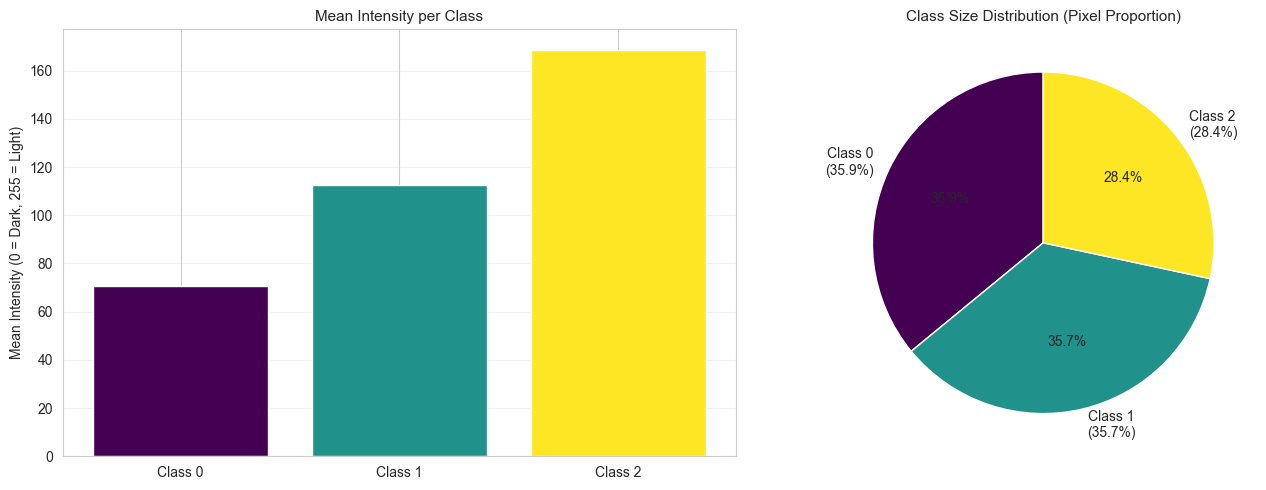

In [64]:
# Plot stats (bar + pie chart)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: Mean intensity per class
axes[0].bar(
    [f'Class {i}' for i in range(num_classes_stats)],
    class_mean_intensities,
    color=plt.cm.viridis(np.linspace(0, 1, num_classes_stats))
)
axes[0].set_title('Mean Intensity per Class', fontsize=11)
axes[0].set_ylabel('Mean Intensity (0 = Dark, 255 = Light)')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart: Class size distribution (shows proportion)
wedges, texts, autotexts = axes[1].pie(
    class_sizes,
    labels=[f'Class {i}\n({size_pct:.1f}%)' for i, size_pct in zip(range(num_classes_stats), (s/regions_stats.size*100 for s in class_sizes))],
    colors=plt.cm.viridis(np.linspace(0, 1, num_classes_stats)),
    autopct='%1.1f%%',  # Show percentage on pie slices
    startangle=90
)
axes[1].set_title('Class Size Distribution (Pixel Proportion)', fontsize=11)

plt.tight_layout()
plt.show()

In [65]:
print("\n📊 Class statistics visualized (pie chart shows how much of the image each class occupies).")


📊 Class statistics visualized (pie chart shows how much of the image each class occupies).


# Step 9: Overlay Segmentation on Original Image
Show where each class is located relative to the original image (transparency overlay)

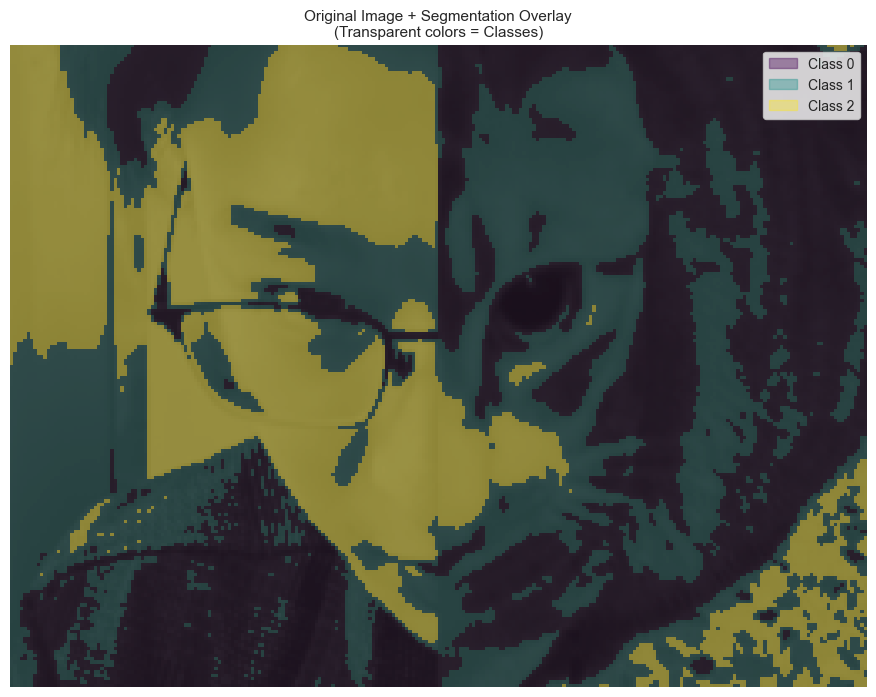

In [66]:
# Create an overlay: Original image (gray) + semi-transparent segmentation
fig, ax = plt.subplots(1, 1, figsize=(9, 7))

# Plot original image first
ax.imshow(resized_img, cmap='gray', alpha=0.7)  # Semi-transparent gray

# Create a mask for each class and overlay with color
colors = plt.cm.viridis(np.linspace(0, 1, num_classes_stats))
for class_num in range(num_classes_stats):
    # Create a mask where only the current class is True
    class_mask = (regions_stats == class_num)
    # Convert mask to RGB (so we can add color)
    mask_rgb = np.zeros((h_resized, w_resized, 3), dtype=np.uint8)
    mask_rgb[class_mask] = (colors[class_num][:3] * 255).astype(np.uint8)  # Convert to 0-255
    # Overlay mask with transparency
    ax.imshow(mask_rgb, alpha=0.4, label=f'Class {class_num}')

# Add legend and labels
ax.set_title('Original Image + Segmentation Overlay\n(Transparent colors = Classes)', fontsize=11)
ax.axis('off')
# Manually add legend (since imshow doesn't support labels directly)
handles = [plt.Rectangle((0,0),1,1, color=colors[i], alpha=0.4) for i in range(num_classes_stats)]
ax.legend(handles, [f'Class {i}' for i in range(num_classes_stats)], loc='upper right')

plt.tight_layout()
plt.show()

In [67]:
print("\n🎨 Segmentation overlay displayed (see exactly where each class is in the original image).")


🎨 Segmentation overlay displayed (see exactly where each class is in the original image).


In [68]:
print("\n🏁 Multi-level Otsu segmentation demo complete!")
print("Key takeaways:")
print("   - More classes → finer intensity separation (but risk of over-segmentation)")
print("   - Thresholds divide the histogram into distinct intensity regions")
print("   - Class statistics show size and brightness distribution across segments")


🏁 Multi-level Otsu segmentation demo complete!
Key takeaways:
   - More classes → finer intensity separation (but risk of over-segmentation)
   - Thresholds divide the histogram into distinct intensity regions
   - Class statistics show size and brightness distribution across segments
